### Import Libraries

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

### Load Metadata

In [2]:
metadata = pd.read_csv("../data/metadata.csv")

# Keep only discharge cycles
metadata = metadata[metadata["type"] == "discharge"].copy()

metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.4671391666146525,NaN,NaN


### Basic Dataset Information

In [3]:
print("Dataset Shape:", metadata.shape)

metadata.info()

metadata.isnull().sum()

Dataset Shape: (2794, 10)
<class 'pandas.DataFrame'>
Index: 2794 entries, 0 to 7563
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   type                 2794 non-null   str  
 1   start_time           2794 non-null   str  
 2   ambient_temperature  2794 non-null   int64
 3   battery_id           2794 non-null   str  
 4   test_id              2794 non-null   int64
 5   uid                  2794 non-null   int64
 6   filename             2794 non-null   str  
 7   Capacity             2794 non-null   str  
 8   Re                   0 non-null      str  
 9   Rct                  0 non-null      str  
dtypes: int64(3), str(7)
memory usage: 506.1 KB


type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity                  0
Re                     2794
Rct                    2794
dtype: int64

### Explore Sample Battery Data

In [4]:
sample = pd.read_csv("../data/raw_data/00001.csv")

sample.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625


### Feature Extraction Function

In [8]:
def extract_features(filename):

    df = pd.read_csv(os.path.join("../data/raw_data", filename))

    return {
        "voltage_mean": df["Voltage_measured"].mean(),
        "voltage_std": df["Voltage_measured"].std(),
        "current_mean": df["Current_measured"].mean(),
        "current_std": df["Current_measured"].std(),
        "temperature_mean": df["Temperature_measured"].mean(),
        "temperature_max": df["Temperature_measured"].max(),
        "current_load_mean": df["Current_load"].mean(),
        "voltage_load_mean": df["Voltage_load"].mean(),
        "time_max": df["Time"].max(),
    }

### Test Feature Extraction

In [10]:
extract_features("00001.csv")

{'voltage_mean': np.float64(3.4752664759657903),
 'voltage_std': np.float64(0.284625579673532),
 'current_mean': np.float64(-0.9527668403077523),
 'current_std': np.float64(0.20144763569935933),
 'temperature_mean': np.float64(8.272422519178683),
 'temperature_max': np.float64(12.376815880696888),
 'current_load_mean': np.float64(0.9571534693877551),
 'voltage_load_mean': np.float64(2.817938775510204),
 'time_max': np.float64(6436.141)}

### Create Feature Dataset

In [14]:
feature_list = []

for _, row in metadata.iterrows():

    features = extract_features(row["filename"])

    features["Capacity"] = row["Capacity"]

    feature_list.append(features)

dataset = pd.DataFrame(feature_list)

dataset.head()

,voltage_mean,voltage_std,current_mean,current_std,temperature_mean,temperature_max,current_load_mean,voltage_load_mean,time_max,Capacity
0,3.475266,0.284626,-0.952767,0.201448,8.272423,12.376816,0.957153,2.817939,6436.141,1.6743047446975208
1,3.476559,0.272495,-0.983889,0.106708,8.210715,11.314903,0.988347,2.881352,5650.265,1.5243662105099023
2,3.470767,0.278535,-0.983889,0.107315,7.954455,11.624528,0.988211,2.884255,5590.907,1.5080762969973425
3,3.467551,0.278416,-0.978947,0.127499,7.985865,11.092924,0.983299,2.843420,5543.610,1.4835577960067696
4,3.462839,0.282585,-0.976262,0.136770,8.009427,11.020979,0.980731,2.829371,5499.046,1.4671391666146525


### Data Cleaning

In [15]:
print(dataset.shape)

dataset.isnull().sum()

dataset = dataset[dataset["Capacity"] != "[]"].copy()

dataset["Capacity"] = dataset["Capacity"].astype(float)

dataset.info()

(2794, 10)
<class 'pandas.DataFrame'>
Index: 2769 entries, 0 to 2793
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   voltage_mean       2769 non-null   float64
 1   voltage_std        2769 non-null   float64
 2   current_mean       2769 non-null   float64
 3   current_std        2769 non-null   float64
 4   temperature_mean   2769 non-null   float64
 5   temperature_max    2769 non-null   float64
 6   current_load_mean  2769 non-null   float64
 7   voltage_load_mean  2769 non-null   float64
 8   time_max           2769 non-null   float64
 9   Capacity           2769 non-null   float64
dtypes: float64(10)
memory usage: 238.0 KB


### Prepare Features & Target

In [16]:
X = dataset.drop("Capacity", axis=1)

y = dataset["Capacity"]

print(X.shape)
print(y.shape)

(2769, 9)
(2769,)


### Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2215, 9)
(554, 9)


### Feature Scaling & Save Scaler

In [23]:
import os
import joblib

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

os.makedirs("../models", exist_ok=True)

joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


### Build Neural Network

In [24]:
model = Sequential(
    [
        Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1),
    ]
)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

c:\Users\rvarj\Desktop\EV-Battery-Life-Prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [25]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6926 - mae: 0.6752 - val_loss: 0.1150 - val_mae: 0.2601
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0641 - mae: 0.1670 - val_loss: 0.0414 - val_mae: 0.1182
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0338 - mae: 0.1054 - val_loss: 0.0287 - val_mae: 0.0899
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0239 - mae: 0.0820 - val_loss: 0.0224 - val_mae: 0.0771
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0184 - mae: 0.0710 - val_loss: 0.0178 - val_mae: 0.0662
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0138 - mae: 0.0597 - val_loss: 0.0195 - val_mae: 0.0949
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0115 - mae: 0.0583 - val_loss: 0.0127 - val_mae: 0.0554
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0094 - mae: 0.0518 - val_loss: 0.0103 - val_mae: 0.0453
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.007

### Evaluate Model

In [27]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
MAE : 0.016328318796716444
MSE : 0.0018539747199783972
RMSE: 0.04305780672512706
R2  : 0.9918205538162139


### Plot Loss Curve & Save Model

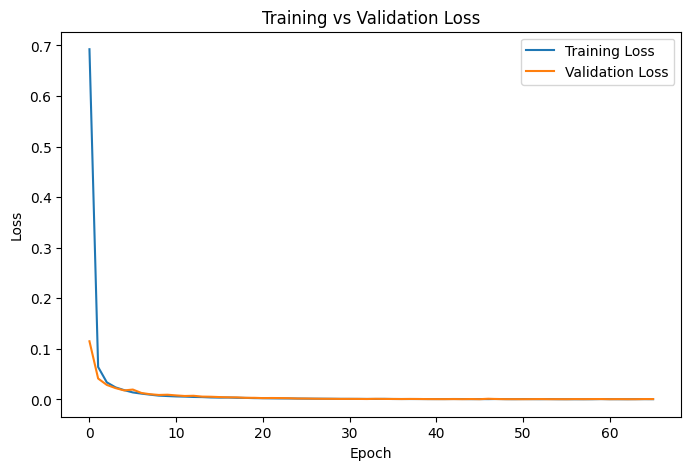

Model Saved Successfully!


In [28]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

model.save("../models/battery_life_model.keras")

print("Model Saved Successfully!")